# Generalization Benchmark Visualization

Reads benchmark config JSONs from `benchmark/results/configs_v2/` for any dataset.

| Figure | Type | Content |
|--------|------|---------|
| **2c. M1 MAE to R1** | Heatmap | M1a→M1g MAE vs R1 (K-Fold CV), per miner |
| **2d. Key Methods MAE to R1** | Heatmap | M1a/M1d/M1g vs M2–M7 MAE vs R1 |

**Usage:** Set `DATASET_KEY = "D1"` (or `"D2"`, `"D3"`, …) in the cell below, then run all.

---

In [26]:
# === Configuration: set your dataset key here ===
DATASET_KEY = "D1"   # ← Change to "D1", "D2", "D3", … "D21"

# === Imports ===
import json, glob, os, re, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
%matplotlib inline

# === Paths ===
CONFIG_DIR = os.path.join(os.getcwd(), "benchmark/results/configs_v2/")

# === Load dataset info ===
sys.path.insert(0, os.getcwd())
from benchmark.datasets import get_info

info = get_info(DATASET_KEY)
DATASET_NAME = info["name"]
DATASET_LABEL = f"{DATASET_KEY} ({DATASET_NAME})"

# === Output directory for saving results ===
OUTPUT_DIR = os.path.join(os.getcwd(), "analysis", "benchmark", DATASET_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Dataset: {DATASET_LABEL}")
print(f"Config dir: {CONFIG_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Dataset: D1 (Sepsis)
Config dir: /home/gengtianhao/Process Mining/benchmark/results/configs_v2/
Output dir: /home/gengtianhao/Process Mining/analysis/benchmark/Sepsis


In [27]:
# === Load all config JSONs for this dataset ===
files = sorted(glob.glob(os.path.join(CONFIG_DIR, f"{DATASET_NAME}__*.json")))
print(f"Found {len(files)} config files for {DATASET_LABEL}")

records = []
for fp in files:
    basename = os.path.basename(fp)
    # Parse: {Dataset}__{Miner}__{Method}.json
    match = re.match(rf'{DATASET_NAME}__(.+)__(\w+)\.json', basename)
    if not match:
        continue
    miner = match.group(1)
    method = match.group(2)
    
    with open(fp, 'r') as f:
        data = json.load(f)
    
    method_label = data.get('method_label', method)
    
    # Extract mean value (handle varied result structures)
    results = data.get('results', {})
    mean = results.get('mean', None)
    std = results.get('std', None)
    
    # M3 special: use entropic_relevance_raw
    if mean is None and 'entropic_relevance_raw' in results:
        mean = results['entropic_relevance_raw']
    
    # M5 Trace_Filtered special: use score field
    if mean is None and 'score' in results:
        mean = results['score']
        std = 0.0
    
    # M6/M7 special: use gen_score field
    if mean is None and 'gen_score' in results:
        mean = results['gen_score']
        if 'std' not in results or results['std'] is None:
            std = 0.0
    
    records.append({
        'miner': miner,
        'method': method,
        'method_label': method_label,
        'mean': mean,
        'std': std,
        'file': basename
    })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} records ({df['method'].nunique()} methods × {df['miner'].nunique()} miners)")
print(f"\nMethods: {sorted(df['method'].unique())}")
print(f"Miners:  {sorted(df['miner'].unique())}")

Found 120 config files for D1 (Sepsis)
Loaded 120 records (15 methods × 8 miners)

Methods: ['M1a', 'M1b', 'M1c', 'M1d', 'M1e', 'M1f', 'M1g', 'M2', 'M3', 'M5', 'M6', 'M7', 'R1', 'R2', 'R3']
Miners:  ['Alpha', 'Alpha+', 'Flower', 'Heuristics', 'Heuristics_Strict', 'Inductive_Infrequent', 'Inductive_Strict', 'Trace_Filtered']


In [28]:
# === Check for missing values ===
pivot_check = df.pivot_table(index='miner', columns='method', values='mean', aggfunc='first')
missing = pivot_check.isna().sum().sum()
print(f"Missing values: {missing}")
if missing > 0:
    print("\nMissing cells:")
    for method in pivot_check.columns:
        na_miners = pivot_check.index[pivot_check[method].isna()].tolist()
        if na_miners:
            print(f"  {method}: {na_miners}")

df.head(3)

Missing values: 0


    miner method               method_label      mean       std  \
0  Alpha+    M1a  HybridGen v1 (1-gram DFG)  0.606224  0.004173   
1  Alpha+    M1b       HybridGen v2.1 (N=3)  0.552151  0.002918   
2  Alpha+    M1c       HybridGen v2.1 (N=6)  0.627083  0.005629   

                       file  
0  Sepsis__Alpha+__M1a.json  
1  Sepsis__Alpha+__M1b.json  
2  Sepsis__Alpha+__M1c.json  

---
## Data Preprocessing

In [29]:
# === Canonical miner order (0.0 pole → 1.0 pole) ===
MINER_ORDER = [
    'Trace_Filtered',   # 0.0 pole: pure memorization
    'Alpha',
    'Alpha+',
    'Heuristics',
    'Heuristics_Strict',
    'Inductive_Strict',
    'Inductive_Infrequent',
    'Flower',           # 1.0 pole: accepts everything
]

# === Method group order ===
METHOD_ORDER_M1 = ['M1a', 'M1b', 'M1c', 'M1d', 'M1e', 'M1f', 'M1g']
METHOD_ORDER_ALL = METHOD_ORDER_M1 + ['M2', 'M3', 'M5', 'M6', 'M7', 'R1', 'R2', 'R3']

METHOD_GROUPS = {
    'HybridGen (M1)': ['M1a', 'M1b', 'M1c', 'M1d', 'M1e', 'M1f', 'M1g'],
    'External': ['M2', 'M3', 'M5', 'M6', 'M7'],
    'Reference': ['R1', 'R2', 'R3'],
}

# === Method label mapping (for display) ===
METHOD_LABELS = {
    'M1a': 'M1a\nv1.0',
    'M1b': 'M1b\nv2.1 N=3',
    'M1c': 'M1c\nv2.1 N=6',
    'M1d': 'M1d\nv2.4',
    'M1e': 'M1e\nv2.5',
    'M1f': 'M1f\nv2.6 log',
    'M1g': 'M1g\nv2.6 MLE',
    'M2': 'M2\nPM4Py',
    'M3': 'M3\nEntropic',
    'M5': 'M5\nAVATAR',
    'M6': 'M6\nBootstrap',
    'M7': 'M7\nSpeciAL',
    'R1': 'R1\nK-Fold CV',
    'R2': 'R2\nLOVO',
    'R3': 'R3\nRandom',
}

MINER_LABELS = {
    'Trace_Filtered': 'Trace\nFiltered',
    'Alpha': 'Alpha',
    'Alpha+': 'Alpha+',
    'Heuristics': 'Heuristics',
    'Heuristics_Strict': 'Heuristics\nStrict',
    'Inductive_Strict': 'Inductive\nStrict',
    'Inductive_Infrequent': 'Inductive\nInfrequent',
    'Flower': 'Flower',
}

# Validate existence
present_miners = set(df['miner'].unique())
present_methods = set(df['method'].unique())
for m in MINER_ORDER:
    assert m in present_miners, f"Miner '{m}' not found in data!"
for m in METHOD_ORDER_ALL:
    assert m in present_methods, f"Method '{m}' not found in data!"
print("✓ All miner/method definitions validated")

✓ All miner/method definitions validated


In [30]:
# === Build Pivot Table (mean values) ===
pivot = df.pivot_table(index='miner', columns='method', values='mean', aggfunc='first')
pivot = pivot.reindex(index=MINER_ORDER, columns=METHOD_ORDER_ALL)

# Same for std
pivot_std = df.pivot_table(index='miner', columns='method', values='std', aggfunc='first')
pivot_std = pivot_std.reindex(index=MINER_ORDER, columns=METHOD_ORDER_ALL)

print("=== Mean Values ===")
display(pivot.round(4))
print("\n=== Std Values ===")
display(pivot_std.round(4))

# === Save summary tables to CSV ===
pivot.round(4).to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_mean.csv"))
pivot_std.round(4).to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_std.csv"))
print(f"\nSaved summary CSVs to: {OUTPUT_DIR}/")

=== Mean Values ===


method                   M1a     M1b     M1c     M1d     M1e     M1f     M1g  \
miner                                                                          
Trace_Filtered        0.5620  0.4956  0.5173  0.5106  0.5085  0.5085  0.5687   
Alpha                 0.2654  0.2841  0.2968  0.2881  0.2849  0.2849  0.2724   
Alpha+                0.6062  0.5522  0.6271  0.6277  0.6512  0.6512  0.7591   
Heuristics            0.8651  0.8214  0.8355  0.8317  0.8457  0.8457  0.8787   
Heuristics_Strict     0.8929  0.8465  0.8535  0.8512  0.8640  0.8640  0.9174   
Inductive_Strict      0.9753  0.9423  0.9557  0.9574  0.9613  0.9613  0.9838   
Inductive_Infrequent  0.9107  0.8901  0.9161  0.9200  0.9310  0.9310  0.9723   
Flower                1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000   

method                    M2       M3      M5      M6      M7      R1      R2  \
miner                                                                           
Trace_Filtered        0.0285  29.8692


=== Std Values ===


method                   M1a     M1b     M1c     M1d     M1e     M1f     M1g  \
miner                                                                          
Trace_Filtered        0.0026  0.0062  0.0054  0.0039  0.0015  0.0015  0.0030   
Alpha                 0.0028  0.0027  0.0031  0.0026  0.0054  0.0054  0.0039   
Alpha+                0.0042  0.0029  0.0056  0.0044  0.0119  0.0119  0.0053   
Heuristics            0.0023  0.0019  0.0012  0.0029  0.0027  0.0027  0.0017   
Heuristics_Strict     0.0021  0.0013  0.0006  0.0030  0.0022  0.0022  0.0015   
Inductive_Strict      0.0015  0.0016  0.0016  0.0009  0.0029  0.0029  0.0020   
Inductive_Infrequent  0.0004  0.0006  0.0014  0.0033  0.0025  0.0025  0.0019   
Flower                0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   

method                 M2  M3      M5   M6   M7      R1      R2      R3  
miner                                                                    
Trace_Filtered        0.0 NaN  0.0000  0.0  0.0  0.


Saved summary CSVs to: /home/gengtianhao/Process Mining/analysis/benchmark/Sepsis/


In [31]:
# === M3 Score Function: raw → [0,1] ===
# M3 (Entropic Relevance) raw value is unbounded (bits saved per trace).
# The theoretically correct normalization is: score = relevance / costOfBackgroundModel.
# However, extensive investigation of all available JAR versions (1.7, 1.7.1, 1.8) found:
#   - The -r flag's internal Relevance.compute() returns a Map with costOfBackgroundModel
#   - But both SimpleBackgroundModel and EventFrequencyBasedBackgroundModel yield
#     costOfBackgroundModel = 0.0 for our DFG models (coverage ≈ 1.0), making
#     the division irrelevant.
#   - The CLI class has a HashMap-order-dependent substring bug (relic from v1.5).
#   - v1.8 cannot be compiled from source due to pre-existing dependency errors.
#
# Conclusion: costOfBackgroundModel is NOT practically available.
# We use a per-dataset global max as fallback: score = min(raw / global_max, 1.0).

# ── Per-dataset M3 normalization parameters ─────────────────────────────────
# Key = dataset name (as in config JSONs); value = global_max_fallback
# Extend this dict as more dataset M3 values become known.
M3_NORM_PARAMS = {
    "Sepsis":              29.87,
    "BPI2013_Incidents":   0.0,
}

def score_m3(raw_value, dataset_name):
    """Map raw entropic relevance to [0,1] using per-dataset global max.
    
    Falls back to clip(raw, 0, 1) if the dataset is not in M3_NORM_PARAMS.
    """
    global_max = M3_NORM_PARAMS.get(dataset_name, None)
    if global_max is not None and global_max > 0:
        return np.clip(raw_value / global_max, 0.0, 1.0)
    else:
        return np.clip(raw_value, 0.0, 1.0)

# ── Apply normalization ─────────────────────────────────────────────────────
pivot_norm = pivot.copy()
m3_raw = pivot['M3'].iloc[0]
m3_normed = score_m3(m3_raw, DATASET_NAME)
pivot_norm['M3'] = m3_normed

m3_note = f"M3: raw={m3_raw:.2f}, normed={m3_normed:.4f} (via score_m3)"
print(m3_note)
print(f"\nValue range per method:")
for col in pivot_norm.columns:
    vals = pivot_norm[col].dropna()
    print(f"  {col:4s}: [{vals.min():.4f}, {vals.max():.4f}]")

M3: raw=29.87, normed=1.0000 (via score_m3)

Value range per method:
  M1a : [0.2654, 1.0000]
  M1b : [0.2841, 1.0000]
  M1c : [0.2968, 1.0000]
  M1d : [0.2881, 1.0000]
  M1e : [0.2849, 1.0000]
  M1f : [0.2849, 1.0000]
  M1g : [0.2724, 1.0000]
  M2  : [0.0285, 0.9189]
  M3  : [1.0000, 1.0000]
  M5  : [0.0000, 0.7506]
  M6  : [0.0000, 0.4609]
  M7  : [0.7443, 1.0000]
  R1  : [0.2748, 1.0000]
  R2  : [0.3059, 1.0000]
  R3  : [0.2779, 1.0000]


---
### Figure 2c: M1 Family MAE to R1 Heatmap

Mean Absolute Error between each M1 version and R1 (K-Fold CV Fitness), per miner.
Lower = better agreement with held-out data. Green = close to R1; Red = far.

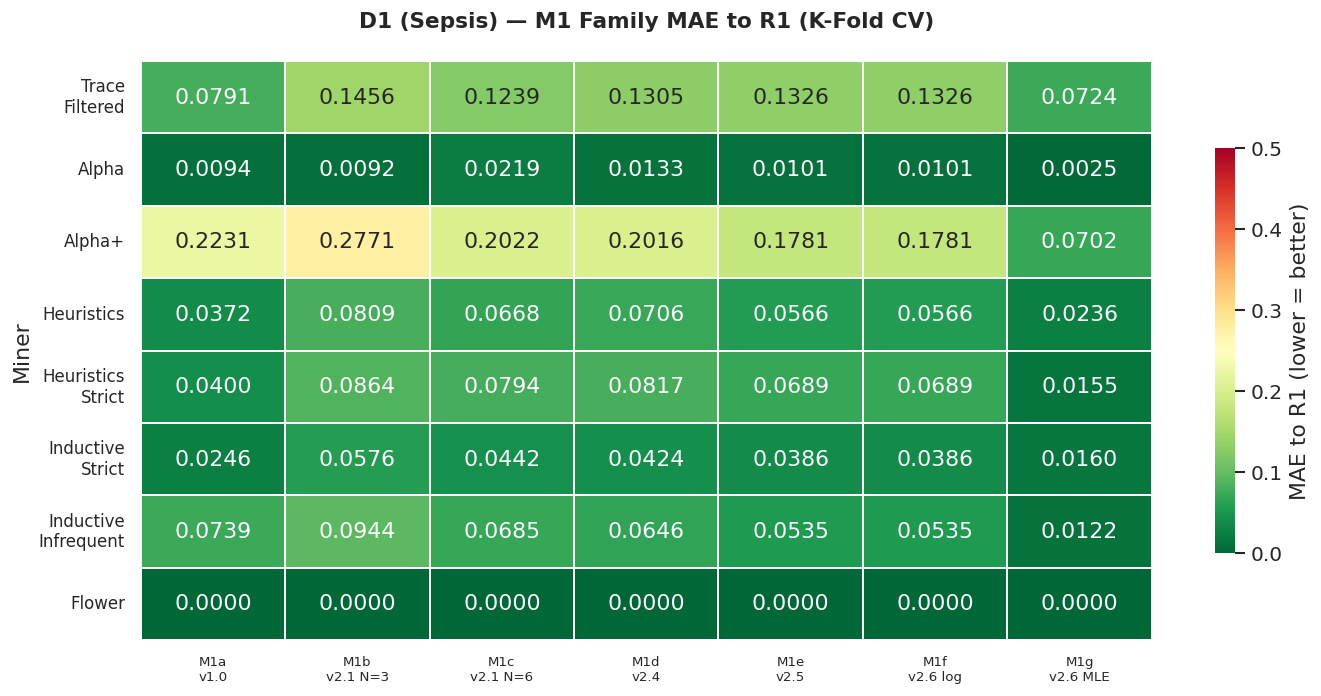

In [32]:
# === Figure 2c: M1 Family MAE to R1 Heatmap ===
METHODS_2C = ['M1a', 'M1b', 'M1c', 'M1d', 'M1e', 'M1f', 'M1g']

r1_vals = pivot_norm['R1']
mae_2c = pd.DataFrame(index=pivot_norm.index, columns=METHODS_2C, dtype=float)
for m in METHODS_2C:
    mae_2c[m] = (pivot_norm[m] - r1_vals).abs()

mae_2c = mae_2c.reindex(index=MINER_ORDER)

annot_2c = np.empty_like(mae_2c.values, dtype=object)
for i in range(len(mae_2c.index)):
    for j in range(len(mae_2c.columns)):
        v = mae_2c.iloc[i, j]
        annot_2c[i, j] = f"{v:.4f}" if not pd.isna(v) else ""

fig, ax = plt.subplots(figsize=(12, 6))
cmap_mae = sns.color_palette("RdYlGn_r", as_cmap=True)

sns.heatmap(
    mae_2c,
    annot=annot_2c,
    fmt='',
    cmap=cmap_mae,
    vmin=0, vmax=0.5,
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'MAE to R1 (lower = better)', 'shrink': 0.7},
    ax=ax
)

ax.set_yticklabels([MINER_LABELS.get(m, m) for m in mae_2c.index], rotation=0, fontsize=10)
ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in mae_2c.columns], rotation=0, fontsize=8)
ax.set_title(f'{DATASET_LABEL} — M1 Family MAE to R1 (K-Fold CV)', fontsize=13, fontweight='bold', pad=20)
ax.set_ylabel('Miner')
ax.set_xlabel('')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_fig2c_m1_mae_to_r1.png"), dpi=150, bbox_inches='tight')
mae_2c.round(4).to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_mae_m1_to_r1.csv"))
plt.show()

---
### Figure 2d: Headline & External Methods MAE to R1

M1a (baseline), M1d (v2.4), M1g (headline) vs external methods M2–M7.
M3 normalized via score_m3() to [0,1] for comparability.

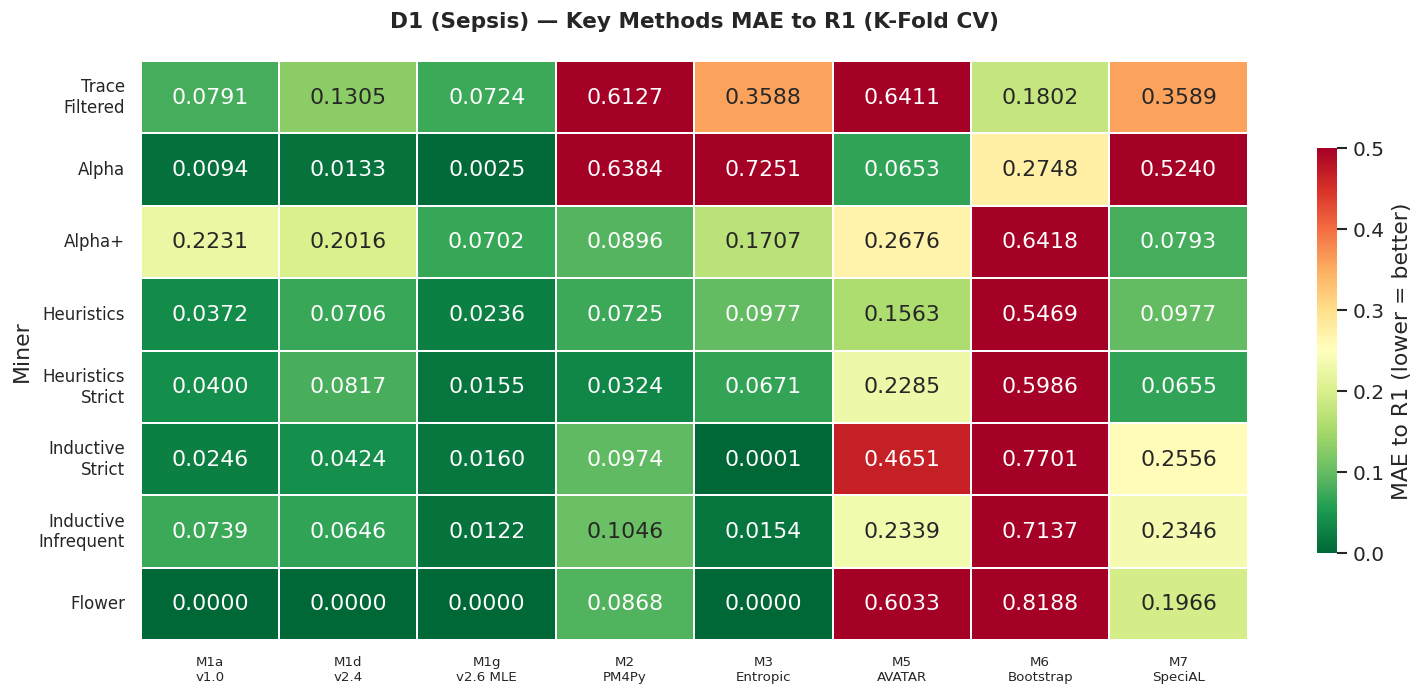

In [33]:
# === Figure 2d: Selected Methods MAE to R1 ===
METHODS_2D = ['M1a', 'M1d', 'M1g', 'M2', 'M3', 'M5', 'M6', 'M7']

r1_vals = pivot_norm['R1']
mae_2d = pd.DataFrame(index=pivot_norm.index, columns=METHODS_2D, dtype=float)
for m in METHODS_2D:
    mae_2d[m] = (pivot_norm[m] - r1_vals).abs()

mae_2d = mae_2d.reindex(index=MINER_ORDER)

annot_2d = np.empty_like(mae_2d.values, dtype=object)
for i in range(len(mae_2d.index)):
    for j in range(len(mae_2d.columns)):
        v = mae_2d.iloc[i, j]
        method = mae_2d.columns[j]
        if pd.isna(v):
            annot_2d[i, j] = ""
        else:
            annot_2d[i, j] = f"{v:.4f}"

fig, ax = plt.subplots(figsize=(13, 6))
cmap_mae = sns.color_palette("RdYlGn_r", as_cmap=True)

sns.heatmap(
    mae_2d,
    annot=annot_2d,
    fmt='',
    cmap=cmap_mae,
    vmin=0, vmax=0.5,
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'MAE to R1 (lower = better)', 'shrink': 0.7},
    ax=ax
)

ax.set_yticklabels([MINER_LABELS.get(m, m) for m in mae_2d.index], rotation=0, fontsize=10)
ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in mae_2d.columns], rotation=0, fontsize=8)
ax.set_title(f'{DATASET_LABEL} — Key Methods MAE to R1 (K-Fold CV)', fontsize=13, fontweight='bold', pad=20)
ax.set_ylabel('Miner')
ax.set_xlabel('')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_fig2d_key_methods_mae_to_r1.png"), dpi=150, bbox_inches='tight')
mae_2d.round(4).to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_mae_key_methods_to_r1.csv"))
plt.show()